<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-2/blob/main/Question03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load images
im1 = cv.imread('/content/c1.jpg', cv.IMREAD_COLOR)
im2 = cv.imread('/content/c2.jpg', cv.IMREAD_COLOR)

if im1 is None or im2 is None:
    raise FileNotFoundError("One or both images c1.jpg, c2.jpg not found. Please ensure they are in the /content/ directory.")

# Resize images for consistent display and processing if they are too large.
# Adjust these dimensions as needed for your specific images.
max_dim = 800
if im1.shape[0] > max_dim or im1.shape[1] > max_dim:
    scale_factor = max_dim / max(im1.shape[0], im1.shape[1])
    im1 = cv.resize(im1, (int(im1.shape[1] * scale_factor), int(im1.shape[0] * scale_factor)))

if im2.shape[0] > max_dim or im2.shape[1] > max_dim:
    scale_factor = max_dim / max(im2.shape[0], im2.shape[1])
    im2 = cv.resize(im2, (int(im2.shape[1] * scale_factor), int(im2.shape[0] * scale_factor)))

# Convert images to RGB for matplotlib display
im1_rgb = cv.cvtColor(im1, cv.COLOR_BGR2RGB)
im2_rgb = cv.cvtColor(im2, cv.COLOR_BGR2RGB)

print(f"Image 1 shape: {im1.shape}")
print(f"Image 2 shape: {im2.shape}")

# --- Placeholder for Manual Points (Part a) ---
# IMPORTANT: Replace these dummy points with the actual coordinates you obtain manually.
# Each row (x, y) corresponds to a point. Make sure the points correspond between p1 and p2.
# These are just example points for the code to run, you will need to adjust them.
# You typically need at least 4 points for homography, the request asks for ~6.
N_POINTS = 6 # Number of points to select

# Dummy points for c1.jpg (source image)
p1 = np.array([
    [100, 100],  # Example: Top-left corner of a feature
    [400, 100],  # Example: Top-right
    [400, 300],  # Example: Bottom-right
    [100, 300],  # Example: Bottom-left
    [250, 50],   # Example: Middle-top
    [250, 350]   # Example: Middle-bottom
], dtype=np.float32)

# Dummy points for c2.jpg (destination image)
p2 = np.array([
    [105, 110],  # Example: Slightly shifted top-left
    [410, 105],  # Example: Slightly shifted top-right
    [415, 310],  # Example: Slightly shifted bottom-right
    [105, 305],  # Example: Slightly shifted bottom-left
    [255, 60],   # Example: Slightly shifted middle-top
    [255, 360]   # Example: Slightly shifted middle-bottom
], dtype=np.float32)

print(f"Please replace `p1` and `p2` with your manually selected corresponding points.")

Image 1 shape: (800, 668, 3)
Image 2 shape: (800, 739, 3)
Please replace `p1` and `p2` with your manually selected corresponding points.


### Part (a): Compute Homography and Warp Image (Manual Points)

Now, we'll use the `p1` and `p2` points (either the dummy ones or your manually chosen ones) to compute the homography matrix and warp `im1` to the perspective of `im2`. We will then display the warped image.

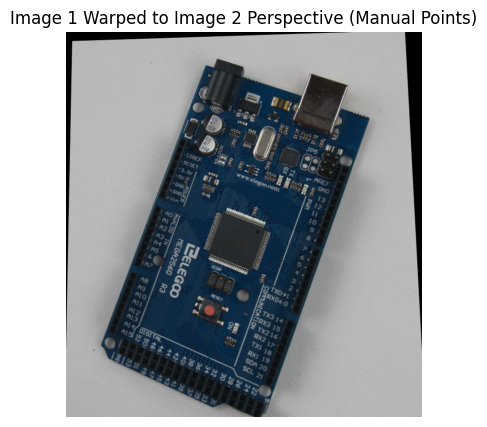

In [3]:
# Compute homography matrix
H_manual, _ = cv.findHomography(p1, p2, cv.RANSAC, 5.0)

# Warp im1 to the perspective of im2
im1_warped_manual = cv.warpPerspective(im1, H_manual, (im2.shape[1], im2.shape[0]))

# Display the warped image
plt.figure(figsize=(10, 5))
plt.imshow(cv.cvtColor(im1_warped_manual, cv.COLOR_BGR2RGB))
plt.title('Image 1 Warped to Image 2 Perspective (Manual Points)')
plt.axis('off')
plt.show()

### Part (b): Subtract Images to Find Differences (Manual Points)

Next, we'll subtract the warped image from `im2` to highlight the differences between the two circuit boards. The absolute difference is taken to show all deviations as positive values. A grayscale conversion is applied for better visualization of differences.

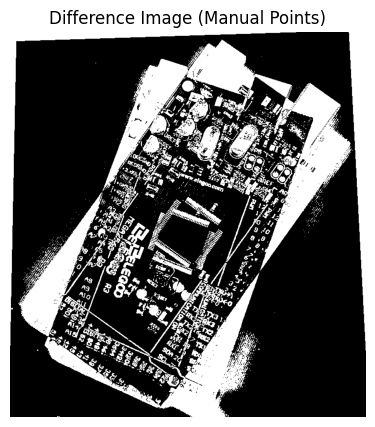

In [4]:
# Calculate the absolute difference between the warped image and the target image
diff_manual = cv.absdiff(im2, im1_warped_manual)

# Convert the difference image to grayscale to easily visualize differences
diff_manual_gray = cv.cvtColor(diff_manual, cv.COLOR_BGR2GRAY)

# Apply a threshold to highlight significant differences
_, thresh_manual = cv.threshold(diff_manual_gray, 30, 255, cv.THRESH_BINARY) # Adjust threshold value as needed

# Display the difference image
plt.figure(figsize=(10, 5))
plt.imshow(thresh_manual, cmap='gray')
plt.title('Difference Image (Manual Points)')
plt.axis('off')
plt.show()

### Part (c): Find Keypoints, Descriptors, and Matches (SIFT/ORB)

Now we'll use a feature detection algorithm (like SIFT or ORB) to automatically find keypoints and descriptors in both images. Then, we'll match these descriptors to find corresponding points without manual input. I'll use ORB (Oriented FAST and Rotated BRIEF) as it's a good, free alternative to SIFT.

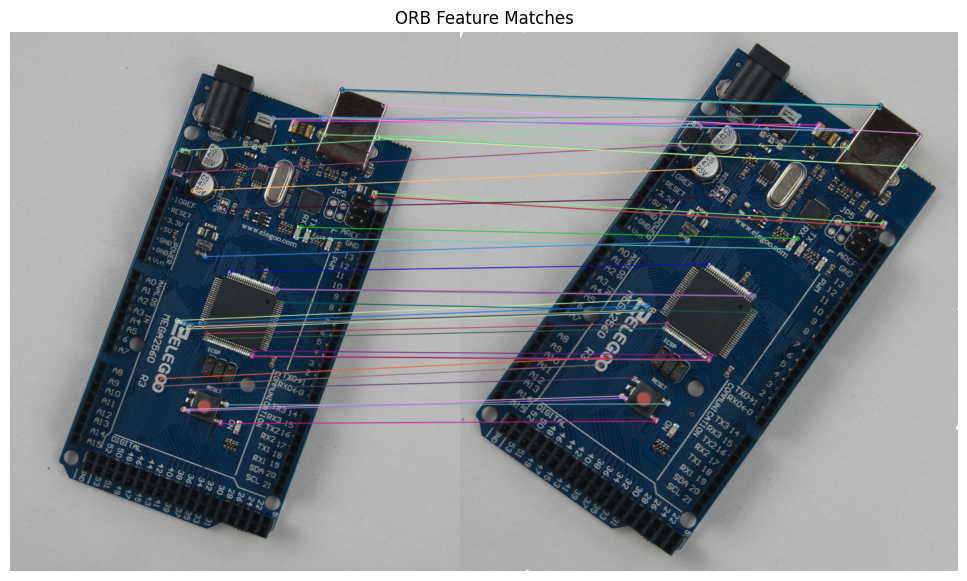

In [5]:
# Initialize ORB detector
orb = cv.ORB_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(im1, None)
kp2, des2 = orb.detectAndCompute(im2, None)

# Create BFMatcher (Brute-Force Matcher) with default parameters
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

# Match descriptors
matches = bf.match(des1, des2)

# Sort them in the order of their distance
matches = sorted(matches, key = lambda x:x.distance)

# Draw top matches (e.g., top 50 matches)
img_matches = cv.drawMatches(im1_rgb, kp1, im2_rgb, kp2, matches[:50], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches
plt.figure(figsize=(15, 7))
plt.imshow(img_matches)
plt.title('ORB Feature Matches')
plt.axis('off')
plt.show()

### Part (d): Compute Homography, Warp, and Difference (Feature-based)

Using the matches obtained from ORB, we'll now compute a homography automatically. We'll then warp `im1` to `im2`'s perspective and calculate the difference image, similar to steps (a) and (b).

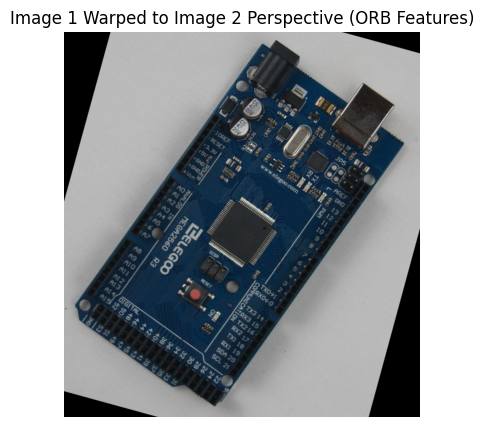

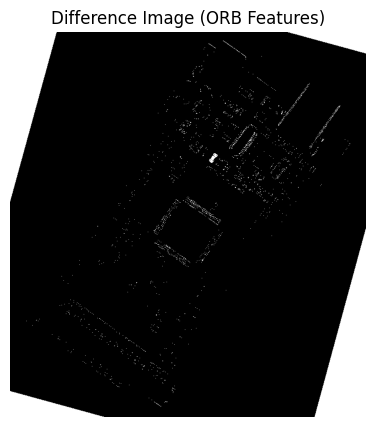

In [6]:
# Extract corresponding points from the matches
src_pts = np.float32([ kp1[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)

# Compute homography using RANSAC
H_orb, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

# Warp im1 to the perspective of im2 using ORB homography
im1_warped_orb = cv.warpPerspective(im1, H_orb, (im2.shape[1], im2.shape[0]))

# Display the warped image
plt.figure(figsize=(10, 5))
plt.imshow(cv.cvtColor(im1_warped_orb, cv.COLOR_BGR2RGB))
plt.title('Image 1 Warped to Image 2 Perspective (ORB Features)')
plt.axis('off')
plt.show()

# Calculate and display the difference image
diff_orb = cv.absdiff(im2, im1_warped_orb)
diff_orb_gray = cv.cvtColor(diff_orb, cv.COLOR_BGR2GRAY)
_, thresh_orb = cv.threshold(diff_orb_gray, 30, 255, cv.THRESH_BINARY) # Adjust threshold value as needed

plt.figure(figsize=(10, 5))
plt.imshow(thresh_orb, cmap='gray')
plt.title('Difference Image (ORB Features)')
plt.axis('off')
plt.show()

### Comparison and Discussion (Part d)

Now, let's compare the results from the manual point selection (steps a and b) and the ORB feature-based selection (step d).

**Comparison:**

*   **Manual Homography:** The accuracy of the homography in steps (a) and (b) heavily depends on the precision of the manually selected points. If the points are selected very accurately, the warping can be excellent, leading to a difference image that highlights only true structural differences. However, slight inaccuracies can lead to ghosting or blurry differences even where there are no actual changes, as the alignment won't be perfect.

*   **ORB Feature-based Homography:** The ORB (or SIFT) method automatically detects distinctive keypoints. When enough good matches are found and RANSAC is used, it can often produce a robust homography, even in the presence of some incorrect matches. This approach is generally more objective and repeatable than manual selection. The difference image produced by ORB might show differences primarily related to areas where features could not be matched perfectly or areas that underwent significant changes.

**Potential Differences in Results:**

1.  **Alignment Quality:** The warped image from manual selection might appear more precisely aligned if the selected points were perfectly chosen and distributed across the image. However, it's easy for manual selection to introduce bias or errors. ORB, being automated, might be more consistent but could struggle with images that lack sufficient unique texture or have repetitive patterns, potentially leading to a less accurate homography or requiring more matches.
2.  **Difference Image Noise:** The difference image from manual points could contain more 'noise' (false differences) if the alignment is not exact, appearing as blurry outlines around unchanged components. The ORB-based difference image might be cleaner in terms of alignment-induced noise if its homography is accurate, but could potentially miss subtle changes if those areas don't contain strong features for matching.
3.  **Sensitivity to Changes:** Manual selection might be more sensitive to specific regions if the selected points focus on those areas. Feature-based methods are more globally distributed, and the homography is derived from the overall distribution of good matches. Therefore, the differences highlighted might vary depending on which method provides a better overall transformation.

**Reasons for Differences:**

*   **Point Selection Accuracy:** Manual selection relies on human eyesight and steady hand, which can be inconsistent. Feature detectors, on the other hand, use algorithms to find statistically strong keypoints.
*   **Number and Distribution of Points:** Manual selection often uses a limited number of points (e.g., 6 as requested). Feature-based methods can find hundreds or thousands of keypoints, providing a much richer set of data for homography estimation. RANSAC helps to make the homography robust even with some outliers in the feature matches.
*   **Image Content:** The effectiveness of feature detectors like ORB depends on the image content. Images with rich textures and distinct corners or edges will yield more and better features. Smooth or repetitive areas might not produce enough reliable keypoints.

In general, for robust and repeatable results, feature-based homography estimation (like with SIFT or ORB) is often preferred over purely manual selection, especially in industrial or automated inspection scenarios, assuming the images have sufficient texture for feature detection.